In [1]:
# save as show_tree.py
import os

def print_tree(start_path='.', max_depth=2, prefix=''):
    def _print(current_path, depth, prefix):
        if depth > max_depth:
            return
        files = sorted(os.listdir(current_path))
        for i, file in enumerate(files):
            path = os.path.join(current_path, file)
            connector = "└── " if i == len(files) - 1 else "├── "
            print(prefix + connector + file)
            if os.path.isdir(path):
                extension = "    " if i == len(files) - 1 else "│   "
                _print(path, depth + 1, prefix + extension)

    print(start_path)
    _print(start_path, 1, '')

if __name__ == "__main__":
    print_tree('../FYS3033DL', max_depth=2)


../FYS3033DL
├── .git
│   ├── COMMIT_EDITMSG
│   ├── FETCH_HEAD
│   ├── HEAD
│   ├── ORIG_HEAD
│   ├── config
│   ├── description
│   ├── hooks
│   ├── index
│   ├── info
│   ├── logs
│   ├── objects
│   └── refs
├── .gitignore
├── FYS3033_homexam.pdf
├── README.md
├── data
│   ├── .DS_Store
│   ├── __MACOSX
│   ├── problem2
│   └── problem3
├── doc
│   ├── report.aux
│   ├── report.fdb_latexmk
│   ├── report.fls
│   ├── report.log
│   ├── report.out
│   ├── report.pdf
│   ├── report.synctex.gz
│   └── report.tex
├── home_exam.ipynb
├── homie_v1.ipynb
├── logs
│   ├── .gitkeep
│   └── VGG11BN_2a_no_dropout_metrics.csv
├── model_without_dropout.pth
├── models
│   ├── .gitkeep
│   ├── VGG11BN_2a_no_dropout_best.pth
│   └── VGG11BN_2a_no_dropout_final.pth
├── plots
│   ├── .gitkeep
│   └── VGG11BN_2a_no_dropout_training.png
├── src
│   ├── .ipynb_checkpoints
│   ├── __pycache__
│   ├── evaluation.py
│   ├── old
│   ├── train.py
│   ├── utils.py
│   └── vgg11bn.py
└── test0404.ipynb


training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


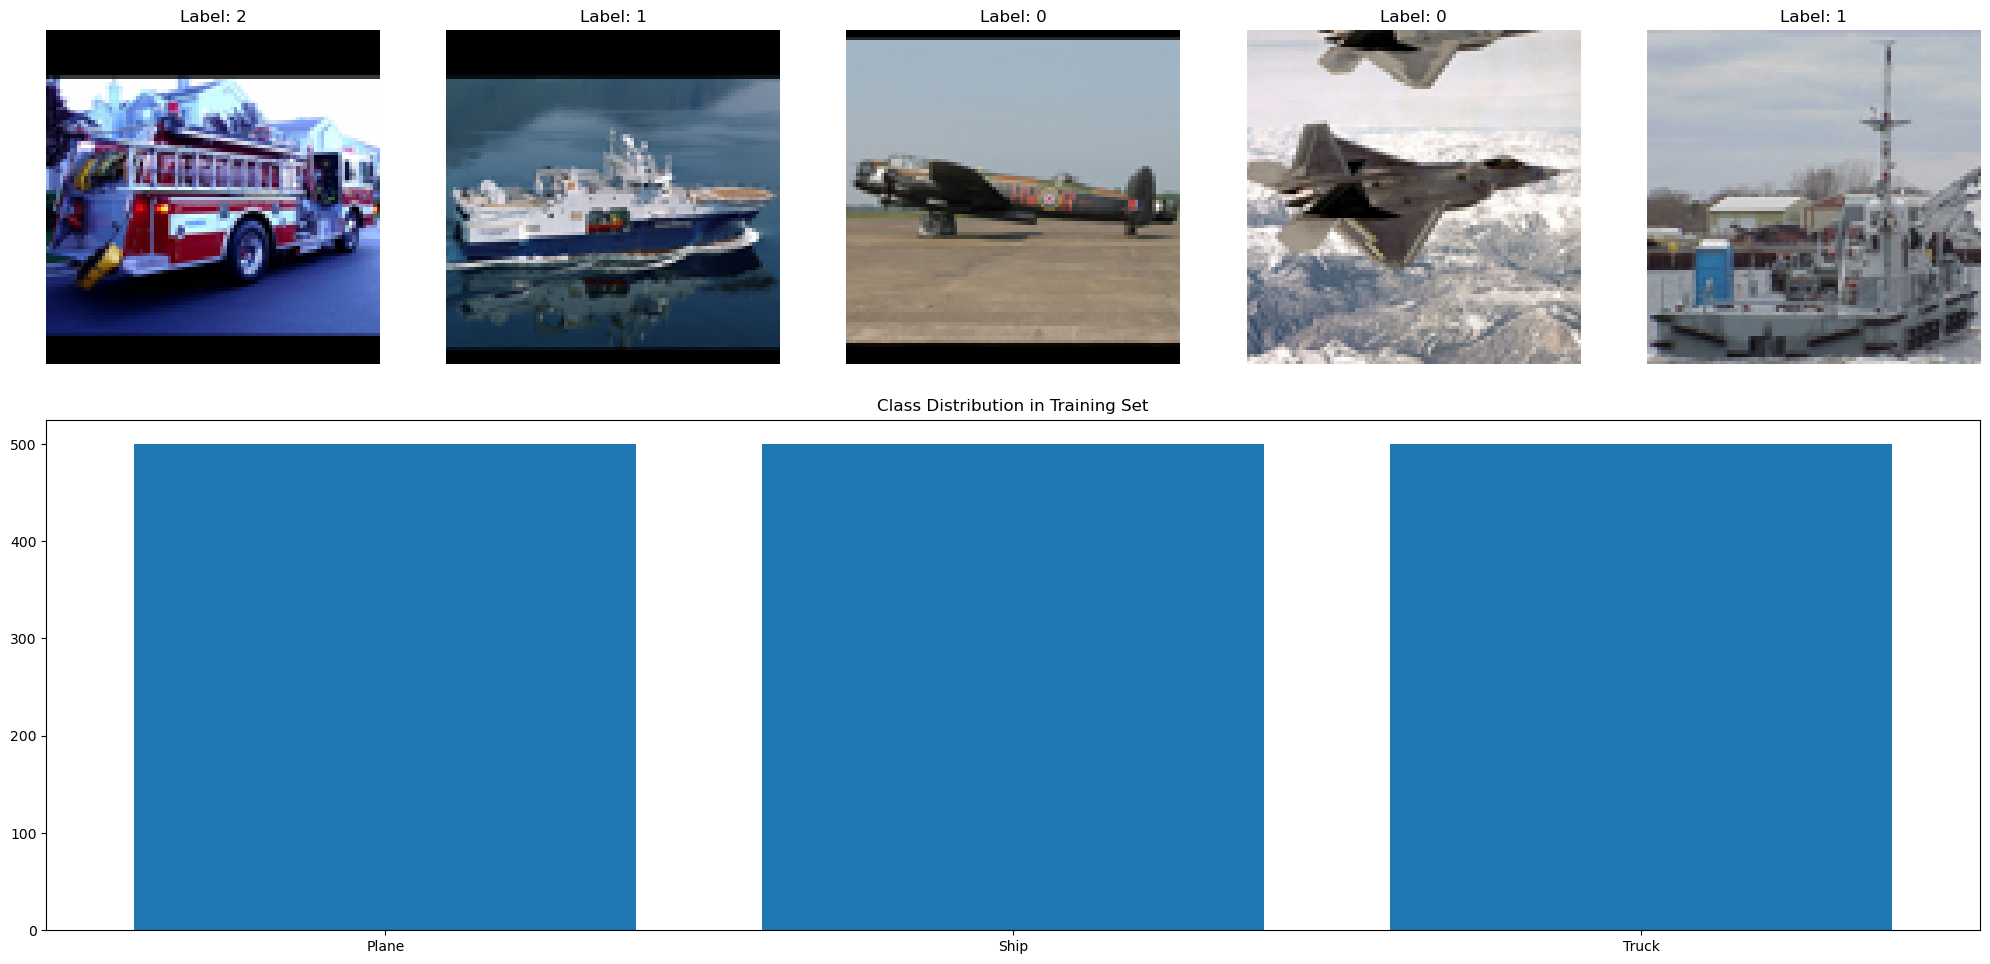

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)
# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


In [3]:
from sklearn.model_selection import train_test_split



# Split indices
train_idx, val_idx = train_test_split(
    np.arange(len(training_labels)),
    test_size=0.2,
    stratify=training_labels,
    random_state=42
)

# Create sets
train_images = training_images[train_idx]
train_labels = training_labels[train_idx]
val_images = training_images[val_idx]
val_labels = training_labels[val_idx]


In [4]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset

# Create datasets
train_dataset = ImageDataset(train_images, train_labels)
val_dataset = ImageDataset(val_images, val_labels)

# Create loaders
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,           #  Shuffles training data each epoch
        pin_memory=True         #  Speeds up transfer to GPU (if using CUDA)
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,          #  Keeps validation consistent across epochs
        pin_memory=True         #  Still helpful for val on GPU
    )
}



Epoch 1/5
----------


New best model found at epoch 1 with accuracy 0.3567

Epoch 2/5
----------


New best model found at epoch 2 with accuracy 0.6233

Epoch 3/5
----------


New best model found at epoch 3 with accuracy 0.7967

Epoch 4/5
----------



Epoch 5/5
----------


New best model found at epoch 5 with accuracy 0.8033

Best val Acc: 0.8033
Total training time: 12.06 seconds


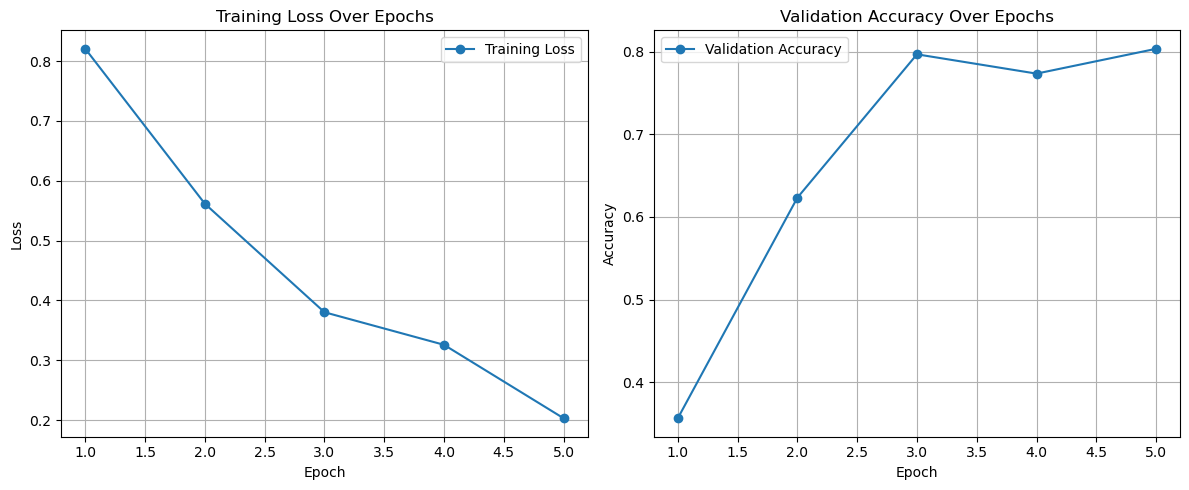


Model without Dropout training complete.
              precision    recall  f1-score   support

       Plane       0.95      0.74      0.83       100
        Ship       0.86      0.72      0.78       100
       Truck       0.69      0.95      0.80       100

    accuracy                           0.80       300
   macro avg       0.83      0.80      0.80       300
weighted avg       0.83      0.80      0.80       300

+------------------------------------------------------+
| Validation Loss: 0.6176, Validation Accuracy: 0.8033 |
+------------------------------------------------------+


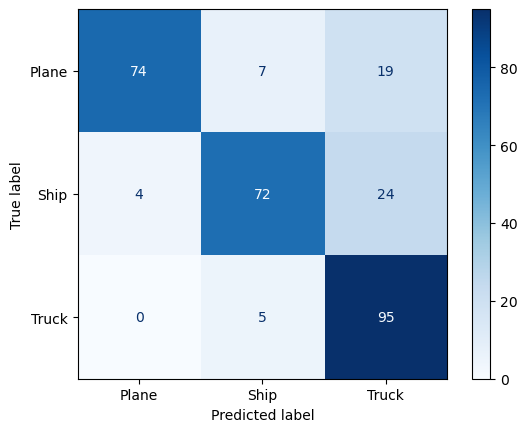

In [ ]:
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.evaluation import classification_summary, plot_confusion_matrix
import torch.optim as optim
import torch.nn as nn
import torch
from torch.optim.lr_scheduler import StepLR

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2a = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2a.parameters(), lr=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model2a,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    device=device,
    num_epochs=100,
    model_name='VGG11BN_2a_no_dropout'

)

print("\nModel without Dropout training complete.")

torch.save(trained_model.state_dict(), 'model_without_dropout.pth')

# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])


In [ ]:

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2a_weightdecay = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2a.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model2a_weightdecay,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    device=device,
    num_epochs=100,
    model_name='VGG11BN_2a_no_dropout_weightdecay'

)

print("\nModel without Dropout training complete.")


# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])


In [ ]:

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2a_weightdecay_scheduler = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2a_weightdecay_scheduler.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model2a_weightdecay_scheduler,
    dataloaders,
    criterion,
    optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=100,
    model_name='VGG11BN_2a_no_dropout_weightdecay_scheduler'

)

print("\nModel without Dropout training complete.")


# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])


In [ ]:
# 2c - with dropout

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2c = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2c.parameters(), lr=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model_name='VGG11BN_2c_with_dropout',
    model=model2c,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    device=device,
    num_epochs=100
)

print("\nModel without Dropout training complete.")



# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])

SyntaxError: positional argument follows keyword argument (2281224252.py, line 28)

In [ ]:
# 2c - with dropout

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2c_weightdecay = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2c_weightdecay.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model_name='VGG11BN_2c_with_dropout_weightdecay',
    model=model2c_weightdecay,
    dataloaders,
    criterion,
    optimizer,
    scheduler=None,
    device=device,
    num_epochs=100
)

print("\nModel without Dropout training complete.")

torch.save(trained_model.state_dict(), 'model_without_dropout.pth')

# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])

In [ ]:
# 2c - with dropout

set_seed(42) # Set seed for reproducibility!

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# cudnn.benchmark = True

# Create model (no dropout for 2a)
model2c_weightdecay_scheduler = VGG11BN(num_classes=3, dropout=False).to(device)

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2c.parameters(), lr=1e-4, weight_decay=1e-4)

# Learning rate scheduler
# StepLR reduces the learning rate by a factor of gamma every step_size epochs
scheduler = StepLR(optimizer, step_size=20, gamma=0.5)

# Train
trained_model = train_model(
    model_name='VGG11BN_2c_with_dropout_weightdecay_scheduler',
    model=model2c,
    dataloaders,
    criterion,
    optimizer,
    scheduler=scheduler,
    device=device,
    num_epochs=100
)

print("\nModel without Dropout training complete.")

torch.save(trained_model.state_dict(), 'model_without_dropout.pth')

# evaluation
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=trained_model,
    dataloader=dataloaders['val'],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print_framed_metrics(val_loss, val_acc)


# Plot confusion matrix
plot_confusion_matrix(trained_model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])